# Análisis de mercado laboral — GEIH
**Fuente:** DANE — Gran Encuesta Integrada de Hogares  
**Procesamiento:** Python + PostgreSQL  

---
### Estructura
1. Conexión y carga única  
2. Función de filtro dinámica  
3. Indicadores básicos (TD, TO, TGP)  
4. Brecha de género  
5. Informalidad  
6. Brecha por edad  
7. Comparativo interanual  
8. Ranking departamental  
9. Región Caribe — análisis completo  
10. Series de tiempo y tendencia  
11. Gráficas  
12. Guardar resultados  

**Para actualizar:** carga el nuevo mes en PostgreSQL y re-ejecuta el notebook.

In [1]:
# ═══════════════════════════════════════════════════════════
# 1. LIBRERÍAS Y CONEXIÓN
# ═══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os, warnings
warnings.filterwarnings('ignore')

load_dotenv('config/.env')
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
with engine.connect() as conn:
    n = conn.execute(text('SELECT COUNT(*) FROM "FUERZA_DE_TRABAJO_GEIH"')).fetchone()[0]
    print(f'Conexión exitosa — {n:,} registros en fuerza de trabajo')

Conexión exitosa — 711,873 registros en fuerza de trabajo


In [14]:
# ═══════════════════════════════════════════════════════════
# 2. CARGA ÚNICA DE DATOS
# ═══════════════════════════════════════════════════════════
# Se ejecuta una sola vez. Todas las celdas siguientes
# trabajan sobre estos DataFrames en memoria.
# Para actualizar: agrega datos en PostgreSQL y re-ejecuta.

# ── Fuerza de trabajo ─────────────────────────────────────
df_ft = pd.read_sql("""
    SELECT
        f."PER"::numeric::integer  AS anno,
        f."MES"                    AS mes,
        f."DPTO"                   AS dpto,
        f."CLASE"::numeric         AS clase,
        f."FEX_C18"::numeric       AS fex,
        f."P6240"::numeric         AS p6240,
        f."P6300"::numeric         AS p6300
    FROM "FUERZA_DE_TRABAJO_GEIH" f
    WHERE f."PET"::numeric = 1
""", engine)

# ── Ocupados (informalidad) ───────────────────────────────
df_ocu = pd.read_sql("""
    SELECT
        o."PER"::numeric::integer  AS anno,
        o."MES"                    AS mes,
        o."DPTO"                   AS dpto,
        o."FEX_C18"::numeric       AS fex,
        o."P6920"::numeric         AS cotiza_pension,
        o."P6430"::numeric         AS posicion_ocu
    FROM "OCUPADOS_GEIH" o
""", engine)

# ── Construir condición de actividad ─────────────────────
def asignar_condicion(p):
    if p in [1.0, 2.0]: return 'Ocupado'
    if p == 3.0:        return 'Desocupado'
    if p in [4.0, 5.0, 6.0]: return 'Inactivo'
    return None

df_ft['condicion'] = df_ft['p6240'].map(asignar_condicion)
df_ft = df_ft.dropna(subset=['condicion'])

# ── Período como fecha ────────────────────────────────────
df_ft['periodo'] = pd.to_datetime(
    df_ft['anno'].astype(str) + '-' + df_ft['mes'] + '-01'
)
df_ocu['periodo'] = pd.to_datetime(
    df_ocu['anno'].astype(str) + '-' + df_ocu['mes'] + '-01'
)

# ── Informal en ocupados ──────────────────────────────────
df_ocu['informal'] = (df_ocu['cotiza_pension'] != 1.0).astype(int)

# ── Detectar cobertura disponible ────────────────────────
ultimo_anno  = int(df_ft['anno'].max())
ultimo_mes   = df_ft[df_ft['anno'] == ultimo_anno]['mes'].max()
anno_anterior = anno_completo  - 1
anno_completo = int(
    df_ft.groupby('anno')['mes'].nunique()
    .pipe(lambda s: s[s == 12]).index.max()
)

print(f'Cobertura: {df_ft["periodo"].min().strftime("%b %Y")} → {df_ft["periodo"].max().strftime("%b %Y")}')
print(f'Año corrido completo disponible: {anno_completo}')
print(f'Último mes disponible: {ultimo_mes}/{ultimo_anno}')
print(f'Departamentos: {df_ft["dpto"].nunique()}')

Cobertura: Jan 2024 → Jan 2025
Año corrido completo disponible: 2024
Último mes disponible: 01/2025
Departamentos: 33


In [15]:
# ═══════════════════════════════════════════════════════════
# 3. FUNCIONES CENTRALES
# ═══════════════════════════════════════════════════════════

MESES_NOMBRES = {
    '01':'Ene','02':'Feb','03':'Mar','04':'Abr',
    '05':'May','06':'Jun','07':'Jul','08':'Ago',
    '09':'Sep','10':'Oct','11':'Nov','12':'Dic'
}
DPTOS_CARIBE = ['08','13','20','23','44','47','70']
NOMBRES_DPTOS = {
    '05':'Antioquia','08':'Atlántico','11':'Bogotá',
    '13':'Bolívar','15':'Boyacá','17':'Caldas',
    '18':'Caquetá','19':'Cauca','20':'Cesar',
    '23':'Córdoba','25':'Cundinamarca','27':'Chocó',
    '41':'Huila','44':'La Guajira','47':'Magdalena',
    '50':'Meta','52':'Nariño','54':'N. Santander',
    '63':'Quindío','66':'Risaralda','68':'Santander',
    '70':'Sucre','73':'Tolima','76':'Valle del Cauca',
    '81':'Arauca','85':'Casanare','86':'Putumayo',
    '88':'San Andrés','91':'Amazonas','94':'Guainía',
    '95':'Guaviare','97':'Vaupés','99':'Vichada'
}

def filtrar(df, anno=None, mes=None, mes_fin=None,
            dptos=None, solo_cabecera=False):
    """
    Filtra el DataFrame base.
    Ejemplos:
      filtrar(df, anno=2024)                    # año corrido 2024
      filtrar(df, anno=2025, mes_fin='03')      # ene-mar 2025
      filtrar(df, anno=[2024,2025], mes='01')   # solo eneros
      filtrar(df, dptos=['13'])                 # Bolívar
    """
    d = df.copy()
    if anno is not None:
        d = d[d['anno'].isin([anno] if not isinstance(anno, list) else anno)]
    if mes is not None:
        d = d[d['mes'].isin([mes] if not isinstance(mes, list) else mes)]
    if mes_fin is not None:
        d = d[d['mes'] <= mes_fin]
    if dptos is not None:
        d = d[d['dpto'].isin(dptos)]
    if solo_cabecera:
        d = d[d['clase'] == 1.0]
    return d


def indicadores(df, agrupar_por):
    """
    Calcula TD, TO, TGP sobre un DataFrame ya filtrado.
    """
    if isinstance(agrupar_por, str):
        agrupar_por = [agrupar_por]
    g = df.groupby(agrupar_por + ['condicion'])['fex'].sum().unstack(fill_value=0)
    ocu = g.get('Ocupado',    0)
    des = g.get('Desocupado', 0)
    ina = g.get('Inactivo',   0)
    pea = ocu + des
    return pd.DataFrame({
        'Ocupados_M': (ocu / 1e6).round(2),
        'Desocup_M':  (des / 1e6).round(2),
        'TD':  (des / pea * 100).round(1),
        'TO':  (ocu / (pea + ina) * 100).round(1),
        'TGP': (pea / (pea + ina) * 100).round(1),
    })

print('Funciones listas: filtrar(), indicadores()')

Funciones listas: filtrar(), indicadores()


In [16]:
# ═══════════════════════════════════════════════════════════
# 4. INDICADORES BÁSICOS
# ═══════════════════════════════════════════════════════════

# ── Año corrido completo ──────────────────────────────────
ind_nac = indicadores(filtrar(df_ft, anno=anno_completo), 'mes')
ind_nac.index = ind_nac.index.map(MESES_NOMBRES)
print(f'Indicadores nacionales — año corrido {anno_completo}')
print(ind_nac[['TD','TO','TGP']].to_string())
print(f'\nPromedio {anno_completo}:  TD={ind_nac["TD"].mean():.1f}%  TO={ind_nac["TO"].mean():.1f}%  TGP={ind_nac["TGP"].mean():.1f}%')

# ── Acumulado año en curso (si difiere del completo) ──────
if ultimo_anno != anno_completo:
    ind_acum = indicadores(filtrar(df_ft, anno=ultimo_anno), 'mes')
    ind_acum.index = ind_acum.index.map(MESES_NOMBRES)
    print(f'\nAcumulado {ultimo_anno} (hasta {MESES_NOMBRES.get(ultimo_mes)})')
    print(ind_acum[['TD','TO','TGP']].to_string())

Indicadores nacionales — año corrido 2024
       TD    TO   TGP
mes                  
Ene  12.1  52.3  59.5
Feb  14.4  54.0  63.1
Mar  15.1  52.2  61.5
Abr  15.6  53.9  63.9
May  15.0  54.4  64.0
Jun  14.5  53.7  62.8
Jul  14.5  54.3  63.5
Ago  15.4  55.0  64.9
Sep  16.4  54.2  64.8
Oct  15.2  54.6  64.4
Nov  15.8  54.8  65.1
Dic  12.5  54.3  62.1

Promedio 2024:  TD=14.7%  TO=54.0%  TGP=63.3%

Acumulado 2025 (hasta Ene)
       TD    TO   TGP
mes                  
Ene  12.5  52.8  60.3


In [17]:
# ═══════════════════════════════════════════════════════════
# 5. INFORMALIDAD
# ═══════════════════════════════════════════════════════════
# Definición DANE: informal = no cotiza a pensión (P6920 != 1)

df_inf_ac = filtrar(df_ocu, anno=anno_completo)

# Nacional por mes
tasa_inf_nac = df_inf_ac.groupby('mes').apply(
    lambda x: (x[x['informal']==1]['fex'].sum() / x['fex'].sum() * 100)
).round(1)
tasa_inf_nac.index = tasa_inf_nac.index.map(MESES_NOMBRES)
print(f'Informalidad nacional — {anno_completo}')
print(tasa_inf_nac.to_frame('Informalidad (%)').to_string())
print(f'Promedio: {tasa_inf_nac.mean():.1f}%')

# Región Caribe
df_inf_caribe = filtrar(df_ocu, anno=anno_completo, dptos=DPTOS_CARIBE)
tasa_inf_caribe = df_inf_caribe.groupby('dpto').apply(
    lambda x: (x[x['informal']==1]['fex'].sum() / x['fex'].sum() * 100)
).round(1).rename(index=NOMBRES_DPTOS).sort_values(ascending=False)
print(f'\nInformalidad región Caribe — {anno_completo}')
print(tasa_inf_caribe.to_frame('Informalidad (%)').to_string())

Informalidad nacional — 2024
     Informalidad (%)
mes                  
Ene              57.0
Feb              58.3
Mar              57.2
Abr              57.2
May              56.4
Jun              57.0
Jul              57.1
Ago              57.0
Sep              56.8
Oct              56.5
Nov              56.3
Dic              58.0
Promedio: 57.1%

Informalidad región Caribe — 2024
            Informalidad (%)
dpto                        
Sucre                   82.7
Córdoba                 81.6
La Guajira              81.2
Magdalena               75.5
Cesar                   72.9
Bolívar                 70.3
Atlántico               62.3


In [18]:
# ═══════════════════════════════════════════════════════════
# 6. BRECHA DE GÉNERO
# ═══════════════════════════════════════════════════════════
# Requiere cruce FT + Características Generales por
# DIRECTORIO + SECUENCIA_P + ORDEN + MES + PER

df_genero = pd.read_sql(f"""
    SELECT
        f."MES" AS mes, f."DPTO" AS dpto,
        f."FEX_C18"::numeric AS fex,
        c."P6016"::numeric AS sexo,
        CASE
            WHEN f."P6240"::numeric IN (1.0,2.0) THEN 'Ocupado'
            WHEN f."P6240"::numeric = 3.0         THEN 'Desocupado'
            WHEN f."P6240"::numeric IN (4.0,5.0,6.0) THEN 'Inactivo'
        END AS condicion
    FROM "FUERZA_DE_TRABAJO_GEIH" f
    JOIN "GEIH_CARACTERISTICAS_GENERALES" c
      ON  f."DIRECTORIO"  = c."DIRECTORIO"
      AND f."SECUENCIA_P" = c."SECUENCIA_P"
      AND f."ORDEN"       = c."ORDEN"
      AND f."MES"         = c."MES"
      AND f."PER"         = c."PER"
    WHERE f."PET"::numeric = 1
    AND   f."PER"::numeric = {anno_completo}
""", engine)

df_genero = df_genero.dropna(subset=['condicion','sexo'])
df_genero['sexo_label'] = df_genero['sexo'].map({1.0:'Hombre', 2.0:'Mujer'})

# TD por sexo y mes
g = df_genero.groupby(['mes','sexo_label','condicion'])['fex'].sum().unstack(fill_value=0)
g['PEA'] = g.get('Ocupado',0) + g.get('Desocupado',0)
g['TD']  = (g.get('Desocupado',0) / g['PEA'] * 100).round(1)
td_g = g['TD'].unstack('sexo_label')
td_g.index = td_g.index.map(MESES_NOMBRES)
td_g['Brecha'] = (td_g['Mujer'] - td_g['Hombre']).round(1)

print(f'Brecha de género en TD — {anno_completo}')
print(td_g.to_string())
print(f'\nBrecha promedio: {td_g["Brecha"].mean():.1f} pp')

# Por región Caribe
df_g_caribe = df_genero[df_genero['dpto'].isin(DPTOS_CARIBE)].copy()
g2 = df_g_caribe.groupby(['dpto','sexo_label','condicion'])['fex'].sum().unstack(fill_value=0)
g2['PEA'] = g2.get('Ocupado',0) + g2.get('Desocupado',0)
g2['TD']  = (g2.get('Desocupado',0) / g2['PEA'] * 100).round(1)
td_g2 = g2['TD'].unstack('sexo_label').rename(index=NOMBRES_DPTOS)
td_g2['Brecha'] = (td_g2['Mujer'] - td_g2['Hombre']).round(1)
print(f'\nBrecha de género Caribe — {anno_completo}')
print(td_g2.sort_values('Brecha', ascending=False).to_string())

Brecha de género en TD — 2024
sexo_label  Hombre  Mujer  Brecha
mes                              
Ene            3.9   11.3     7.4
Feb            5.4   14.4     9.0
Mar            5.3   15.1     9.8
Abr            5.7   15.7    10.0
May            5.2   15.4    10.2
Jun            4.9   14.1     9.2
Jul            5.1   14.4     9.3
Ago            5.2   16.2    11.0
Sep            6.0   16.7    10.7
Oct            5.5   15.3     9.8
Nov            6.1   15.3     9.2
Dic            4.5   12.4     7.9

Brecha promedio: 9.5 pp

Brecha de género Caribe — 2024
sexo_label  Hombre  Mujer  Brecha
dpto                             
Sucre          1.2   14.7    13.5
Bolívar        3.9   16.2    12.3
Córdoba        5.1   16.8    11.7
La Guajira     5.3   17.0    11.7
Magdalena      5.1   15.6    10.5
Atlántico      3.9   14.1    10.2
Cesar         11.9   20.6     8.7


In [19]:
# ═══════════════════════════════════════════════════════════
# 7. BRECHA POR EDAD
# ═══════════════════════════════════════════════════════════

df_edad = pd.read_sql(f"""
    SELECT
        f."MES" AS mes, f."DPTO" AS dpto,
        f."FEX_C18"::numeric AS fex,
        c."P6040"::numeric AS edad,
        CASE
            WHEN f."P6240"::numeric IN (1.0,2.0) THEN 'Ocupado'
            WHEN f."P6240"::numeric = 3.0         THEN 'Desocupado'
            WHEN f."P6240"::numeric IN (4.0,5.0,6.0) THEN 'Inactivo'
        END AS condicion
    FROM "FUERZA_DE_TRABAJO_GEIH" f
    JOIN "GEIH_CARACTERISTICAS_GENERALES" c
      ON  f."DIRECTORIO"  = c."DIRECTORIO"
      AND f."SECUENCIA_P" = c."SECUENCIA_P"
      AND f."ORDEN"       = c."ORDEN"
      AND f."MES"         = c."MES"
      AND f."PER"         = c."PER"
    WHERE f."PET"::numeric = 1
    AND   f."PER"::numeric = {anno_completo}
""", engine)

df_edad = df_edad.dropna(subset=['condicion','edad'])

def grupo_etario(e):
    if 18 <= e <= 28: return '1. Jóvenes (18-28)'
    if 29 <= e <= 54: return '2. Adultos (29-54)'
    if e >= 55:       return '3. Mayores (55+)'
    return None

df_edad['grupo'] = df_edad['edad'].map(grupo_etario)
df_edad = df_edad.dropna(subset=['grupo'])

# Nacional por grupo
g = df_edad.groupby(['grupo','condicion'])['fex'].sum().unstack(fill_value=0)
g['PEA'] = g.get('Ocupado',0) + g.get('Desocupado',0)
g['TD']  = (g.get('Desocupado',0) / g['PEA'] * 100).round(1)
g['TGP'] = (g['PEA'] / (g['PEA'] + g.get('Inactivo',0)) * 100).round(1)
g['TO']  = (g.get('Ocupado',0) / (g['PEA'] + g.get('Inactivo',0)) * 100).round(1)

print(f'Indicadores por grupo etario — {anno_completo}')
print(g[['TD','TO','TGP']].to_string())

brecha_edad = (g.loc['1. Jóvenes (18-28)','TD'] - g.loc['2. Adultos (29-54)','TD']).round(1)
print(f'\nBrecha jóvenes vs adultos: {brecha_edad:+.1f} pp')
print('(positivo = jóvenes tienen más desempleo que adultos)')

# Caribe por grupo
g_c = df_edad[df_edad['dpto'].isin(DPTOS_CARIBE)].groupby(['dpto','grupo','condicion'])['fex'].sum().unstack(fill_value=0)
g_c['PEA'] = g_c.get('Ocupado',0) + g_c.get('Desocupado',0)
g_c['TD']  = (g_c.get('Desocupado',0) / g_c['PEA'] * 100).round(1)
td_edad_caribe = g_c['TD'].unstack('grupo')
td_edad_caribe.index = td_edad_caribe.index.map(NOMBRES_DPTOS)
print(f'\nTD por grupo etario — región Caribe {anno_completo}')
print(td_edad_caribe.to_string())

Indicadores por grupo etario — 2024
condicion             TD    TO   TGP
grupo                               
1. Jóvenes (18-28)  25.4  55.8  74.8
2. Adultos (29-54)   0.8  71.3  71.9
3. Mayores (55+)     0.2  34.2  34.3

Brecha jóvenes vs adultos: +24.6 pp
(positivo = jóvenes tienen más desempleo que adultos)

TD por grupo etario — región Caribe 2024
grupo       1. Jóvenes (18-28)  2. Adultos (29-54)  3. Mayores (55+)
dpto                                                                
Atlántico                 33.9                 0.7               0.0
Bolívar                   32.8                 0.6               0.2
Cesar                     30.2                 1.1               0.0
Córdoba                   27.2                 0.5               0.0
La Guajira                27.8                 0.7               0.0
Magdalena                 29.1                 0.8               0.1
Sucre                     36.1                 0.7               0.0


In [27]:
# ═══════════════════════════════════════════════════════════
# 8. COMPARATIVO INTERANUAL
# ═══════════════════════════════════════════════════════════

meses_en_curso = sorted(df_ft[df_ft['anno'] == ultimo_anno]['mes'].unique())
anno_para_comparar = anno_completo - 1  # año anterior al completo disponible

# Verificar si hay datos del año anterior
annos_disponibles = df_ft['anno'].unique()

if anno_para_comparar not in annos_disponibles:
    print(f"No hay datos de {anno_para_comparar} en la base.")
    print(f"El comparativo estará disponible cuando cargues los datos de {anno_para_comparar}.")
    print(f"Años disponibles: {sorted(annos_disponibles)}")
else:
    ind_actual   = indicadores(filtrar(df_ft, anno=ultimo_anno,        mes=meses_en_curso), 'mes')
    ind_anterior = indicadores(filtrar(df_ft, anno=anno_para_comparar, mes=meses_en_curso), 'mes')

    comp = pd.DataFrame({
        f'TD_{anno_para_comparar}': ind_anterior['TD'],
        f'TD_{ultimo_anno}':        ind_actual['TD'],
        'var_pp': (ind_actual['TD'] - ind_anterior['TD']).round(1)
    })
    comp.index = comp.index.map(MESES_NOMBRES)

    print(f'Comparativo interanual — {anno_para_comparar} vs {ultimo_anno}')
    print(f'Meses comparables: {[MESES_NOMBRES[m] for m in meses_en_curso]}')
    print(comp.to_string())

    var_media = comp['var_pp'].mean().round(1)
    signo = "+" if var_media > 0 else ""
    print(f'Variacion promedio: {signo}{var_media} pp')

No hay datos de 2023 en la base.
El comparativo estará disponible cuando cargues los datos de 2023.
Años disponibles: [np.int64(2024), np.int64(2025)]


In [28]:
# ═══════════════════════════════════════════════════════════
# 9. RANKING DEPARTAMENTAL
# ═══════════════════════════════════════════════════════════

ind_rank = indicadores(filtrar(df_ft, anno=anno_completo), 'dpto')
ind_rank.index = ind_rank.index.map(NOMBRES_DPTOS)
ind_rank = ind_rank.sort_values('TD', ascending=False)

print(f'Ranking departamental por TD — {anno_completo}')
print(ind_rank[['TD','TO','TGP']].to_string())

print(f'\nPosición región Caribe en el ranking:')
for dpto_cod in DPTOS_CARIBE:
    nombre = NOMBRES_DPTOS.get(dpto_cod, dpto_cod)
    if nombre in ind_rank.index:
        pos = list(ind_rank.index).index(nombre) + 1
        td  = ind_rank.loc[nombre, 'TD']
        print(f'  {nombre:<20} Puesto {pos:>2}/33   TD: {td}%')

Ranking departamental por TD — 2024
                   TD    TO   TGP
dpto                             
Chocó            27.1  34.5  47.3
Guainía          21.1  53.1  67.3
Amazonas         20.2  57.5  72.1
Sucre            20.0  45.5  56.8
Cesar            18.9  48.8  60.2
Magdalena        18.6  50.2  61.7
Bolívar          18.5  51.3  62.9
La Guajira       18.4  51.3  62.9
Putumayo         18.1  61.2  74.8
Atlántico        17.8  53.7  65.3
Boyacá           17.7  49.0  59.5
Córdoba          17.5  47.2  57.2
Vaupés           17.1  53.2  64.2
N. Santander     15.5  49.0  57.9
Valle del Cauca  14.8  53.7  63.0
Tolima           14.8  51.4  60.3
Huila            14.5  56.1  65.6
Cauca            14.3  51.9  60.5
Meta             13.8  55.7  64.6
Caquetá          13.6  53.2  61.6
Arauca           13.5  60.6  70.1
Antioquia        13.4  53.8  62.1
Quindío          13.2  51.9  59.8
Santander        13.2  55.3  63.7
Nariño           13.1  53.0  61.1
Casanare         13.0  66.5  76.4
Bogotá      

In [31]:
# ═══════════════════════════════════════════════════════════
# 10. REGIÓN CARIBE — ANÁLISIS COMPLETO
# ═══════════════════════════════════════════════════════════

# Año corrido por departamento
ind_caribe = indicadores(filtrar(df_ft, anno=anno_completo, dptos=DPTOS_CARIBE), 'dpto')
ind_caribe.index = ind_caribe.index.map(NOMBRES_DPTOS)
ind_caribe = ind_caribe.sort_values('TD', ascending=False)
print(f'Región Caribe — año corrido {anno_completo}')
print(ind_caribe[['TD','TO','TGP']].to_string())

# Bolívar mes a mes
ind_bolivar = indicadores(filtrar(df_ft, anno=anno_completo, dptos=['13']), 'mes')
ind_bolivar.index = ind_bolivar.index.map(MESES_NOMBRES)
print(f'\nBolívar — mes a mes {anno_completo}')
print(ind_bolivar[['TD','TO','TGP']].to_string())

# Comparativo interanual Caribe — solo si hay datos del año anterior
anno_caribe_ant = anno_completo - 1
annos_disponibles = df_ft['anno'].unique()

if anno_caribe_ant not in annos_disponibles:
    print(f'\nComparativo interanual no disponible.')
    print(f'Carga datos de {anno_caribe_ant} para activar esta sección.')
else:
    ind_caribe_ant = indicadores(filtrar(df_ft, anno=anno_caribe_ant, dptos=DPTOS_CARIBE), 'dpto')
    ind_caribe_ant.index = ind_caribe_ant.index.map(NOMBRES_DPTOS)
    comp_caribe = pd.DataFrame({
        f'TD_{anno_caribe_ant}': ind_caribe_ant['TD'],
        f'TD_{anno_completo}':   ind_caribe['TD'],
        'var_pp': (ind_caribe['TD'] - ind_caribe_ant['TD']).round(1)
    }).sort_values(f'TD_{anno_completo}', ascending=False)
    print(f'\nComparativo Caribe — {anno_caribe_ant} vs {anno_completo}')
    print(comp_caribe.to_string())

Región Caribe — año corrido 2024
              TD    TO   TGP
dpto                        
Sucre       20.0  45.5  56.8
Cesar       18.9  48.8  60.2
Magdalena   18.6  50.2  61.7
Bolívar     18.5  51.3  62.9
La Guajira  18.4  51.3  62.9
Atlántico   17.8  53.7  65.3
Córdoba     17.5  47.2  57.2

Bolívar — mes a mes 2024
       TD    TO   TGP
mes                  
Ene  15.4  56.1  66.3
Feb  16.4  52.7  63.1
Mar  19.8  51.0  63.5
Abr  19.3  49.8  61.7
May  18.4  50.8  62.2
Jun  21.7  47.8  61.1
Jul  20.0  48.6  60.7
Ago  19.2  51.2  63.4
Sep  19.9  51.2  63.9
Oct  16.7  54.8  65.8
Nov  19.6  50.1  62.3
Dic  15.5  51.2  60.5

Comparativo interanual no disponible.
Carga datos de 2023 para activar esta sección.


In [32]:
# ═══════════════════════════════════════════════════════════
# 11. SERIES DE TIEMPO Y TENDENCIA
# ═══════════════════════════════════════════════════════════

# Serie completa nacional
ind_serie = indicadores(df_ft, ['anno','mes']).reset_index()
ind_serie['periodo'] = pd.to_datetime(
    ind_serie['anno'].astype(str) + '-' + ind_serie['mes'] + '-01'
)
ind_serie = ind_serie.sort_values('periodo')
ind_serie['TD_mm3'] = ind_serie['TD'].rolling(3, center=True).mean().round(1)

# Serie Bolívar completa
ind_bol_serie = indicadores(filtrar(df_ft, dptos=['13']), ['anno','mes']).reset_index()
ind_bol_serie['periodo'] = pd.to_datetime(
    ind_bol_serie['anno'].astype(str) + '-' + ind_bol_serie['mes'] + '-01'
)
ind_bol_serie = ind_bol_serie.sort_values('periodo')
ind_bol_serie['TD_mm3'] = ind_bol_serie['TD'].rolling(3, center=True).mean().round(1)

print('Serie completa nacional:')
print(ind_serie[['periodo','TD','TD_mm3','TO','TGP']].to_string(index=False))

Serie completa nacional:
   periodo   TD  TD_mm3   TO  TGP
2024-01-01 12.1     NaN 52.3 59.5
2024-02-01 14.4    13.9 54.0 63.1
2024-03-01 15.1    15.0 52.2 61.5
2024-04-01 15.6    15.2 53.9 63.9
2024-05-01 15.0    15.0 54.4 64.0
2024-06-01 14.5    14.7 53.7 62.8
2024-07-01 14.5    14.8 54.3 63.5
2024-08-01 15.4    15.4 55.0 64.9
2024-09-01 16.4    15.7 54.2 64.8
2024-10-01 15.2    15.8 54.6 64.4
2024-11-01 15.8    14.5 54.8 65.1
2024-12-01 12.5    13.6 54.3 62.1
2025-01-01 12.5     NaN 52.8 60.3


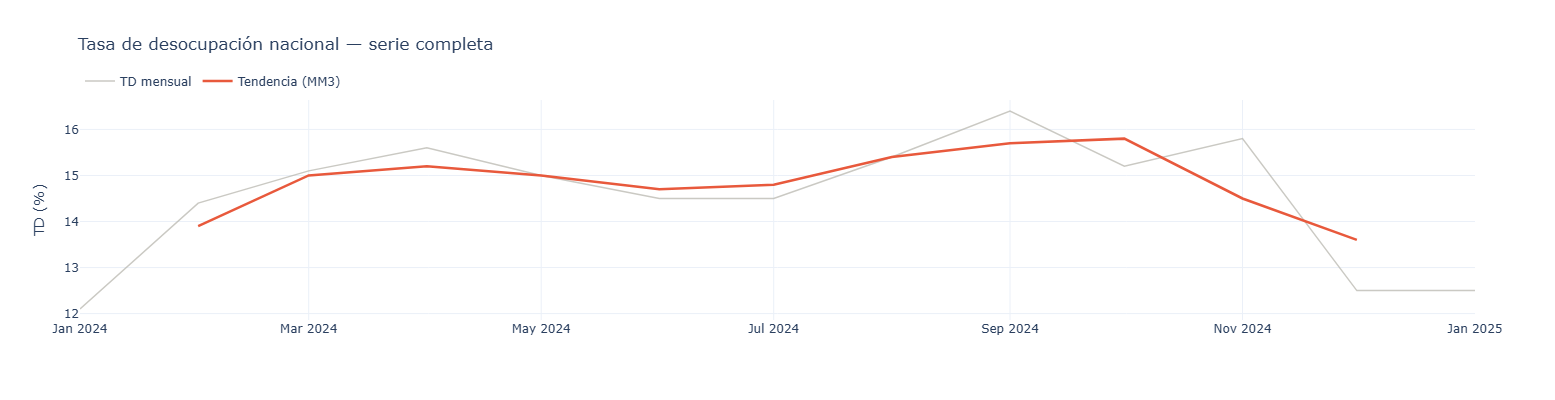

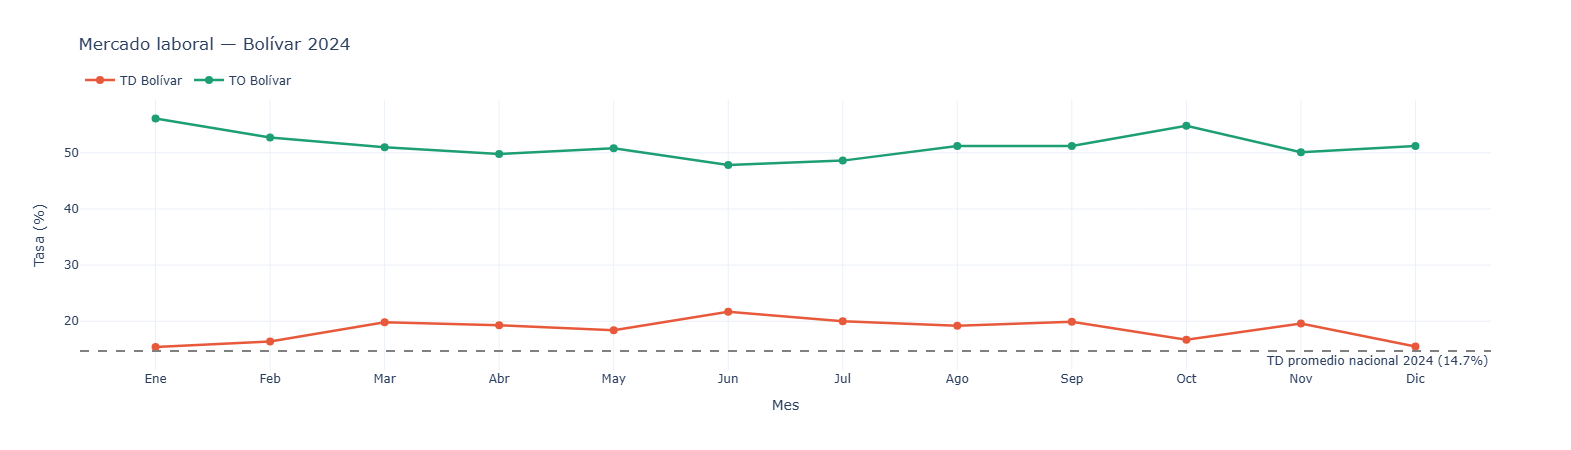

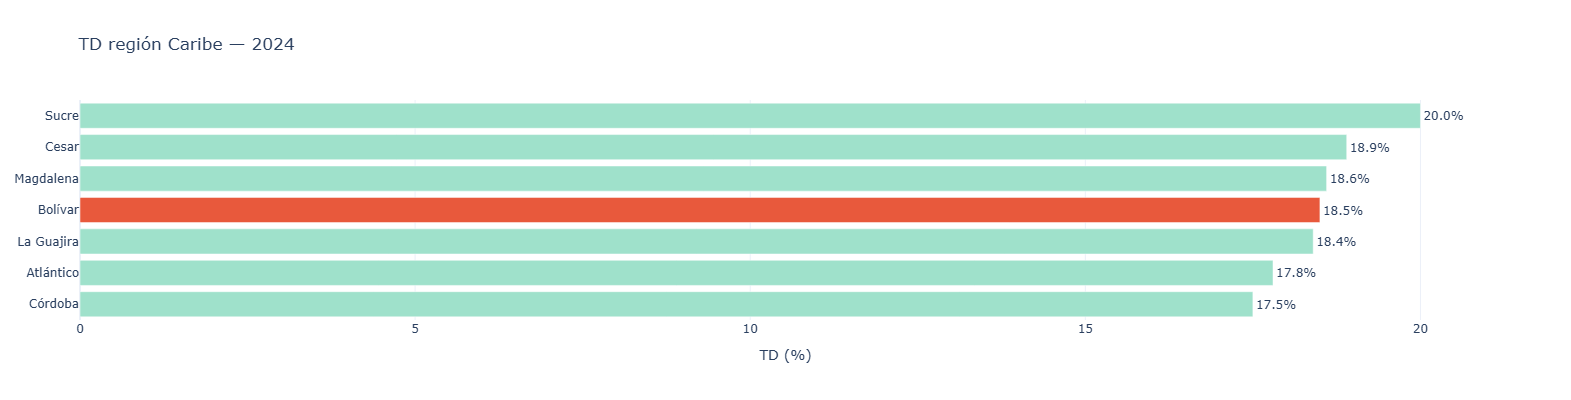

G4 no disponible — carga datos de 2023 para activar.


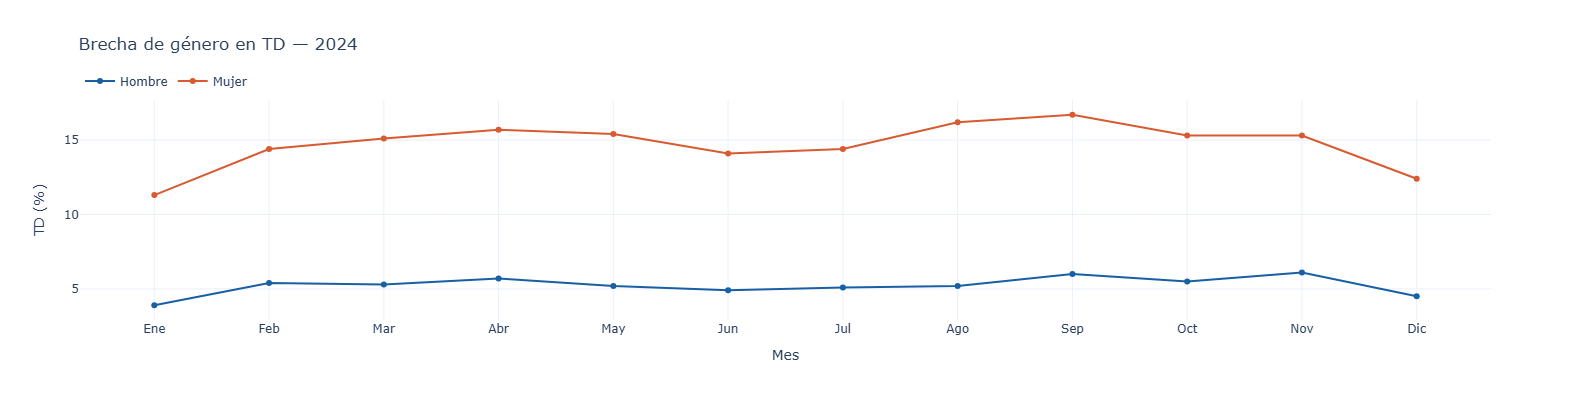

In [36]:
# ═══════════════════════════════════════════════════════════
# 12. GRÁFICAS
# ═══════════════════════════════════════════════════════════

# ── G1: Serie completa nacional con tendencia ─────────────
fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=ind_serie['periodo'], y=ind_serie['TD'],
    mode='lines', name='TD mensual',
    line=dict(color='#B4B2A9', width=1.5), opacity=0.7
))
fig1.add_trace(go.Scatter(
    x=ind_serie['periodo'], y=ind_serie['TD_mm3'],
    mode='lines', name='Tendencia (MM3)',
    line=dict(color='#E8593C', width=2.5)
))
fig1.update_layout(
    title='Tasa de desocupación nacional — serie completa',
    xaxis_title='', yaxis_title='TD (%)',
    template='plotly_white', height=400,
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig1.show()

# ── G2: Bolívar mes a mes con referencia nacional ─────────
td_ref = ind_nac['TD'].mean().round(1)
fig2 = go.Figure()
fig2.add_trace(go.Scatter(
    x=ind_bolivar.index, y=ind_bolivar['TD'],
    mode='lines+markers', name='TD Bolívar',
    line=dict(color='#E8593C', width=2.5), marker=dict(size=8)
))
fig2.add_trace(go.Scatter(
    x=ind_bolivar.index, y=ind_bolivar['TO'],
    mode='lines+markers', name='TO Bolívar',
    line=dict(color='#1D9E75', width=2.5), marker=dict(size=8)
))
fig2.add_hline(
    y=td_ref, line_dash='dash', line_color='gray',
    annotation_text=f'TD promedio nacional {anno_completo} ({td_ref}%)',
    annotation_position='bottom right'
)
fig2.update_layout(
    title=f'Mercado laboral — Bolívar {anno_completo}',
    xaxis_title='Mes', yaxis_title='Tasa (%)',
    template='plotly_white', height=450,
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig2.show()

# ── G3: Ranking Caribe ────────────────────────────────────
colores = ['#E8593C' if d == 'Bolívar' else '#9FE1CB' for d in ind_caribe.index]
fig3 = go.Figure(go.Bar(
    x=ind_caribe['TD'], y=ind_caribe.index, orientation='h',
    marker_color=colores,
    text=ind_caribe['TD'].astype(str)+'%', textposition='outside'
))
fig3.update_layout(
    title=f'TD región Caribe — {anno_completo}',
    xaxis_title='TD (%)', template='plotly_white', height=400,
    yaxis={'categoryorder':'total ascending'}
)
fig3.show()

# ── G4: Comparativo interanual Caribe ─────────────────────
if 'comp_caribe' in dir() and f'TD_{anno_caribe_ant}' in comp_caribe.columns:
    fig4 = go.Figure()
    fig4.add_trace(go.Bar(
        name=str(anno_caribe_ant),
        x=comp_caribe.index,
        y=comp_caribe[f'TD_{anno_caribe_ant}'],
        marker_color='#B4B2A9'
    ))
    fig4.add_trace(go.Bar(
        name=str(anno_completo),
        x=comp_caribe.index,
        y=comp_caribe[f'TD_{anno_completo}'],
        marker_color='#E8593C'
    ))
    fig4.update_layout(
        title='Comparativo interanual — región Caribe',
        barmode='group', yaxis_title='TD (%)',
        template='plotly_white', height=400,
        legend=dict(orientation='h', yanchor='bottom', y=1.02)
    )
    fig4.show()
else:
    print(f'G4 no disponible — carga datos de {anno_completo - 1} para activar.')

# ── G5: Brecha de género por mes ──────────────────────────
fig5 = go.Figure()
fig5.add_trace(go.Scatter(
    x=td_g.index, y=td_g['Hombre'],
    mode='lines+markers', name='Hombre',
    line=dict(color='#185FA5', width=2)
))
fig5.add_trace(go.Scatter(
    x=td_g.index, y=td_g['Mujer'],
    mode='lines+markers', name='Mujer',
    line=dict(color='#D85A30', width=2)
))
fig5.update_layout(
    title=f'Brecha de género en TD — {anno_completo}',
    xaxis_title='Mes', yaxis_title='TD (%)',
    template='plotly_white', height=400,
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig5.show()

In [37]:
# ═══════════════════════════════════════════════════════════
# 13. GUARDAR RESULTADOS
# ═══════════════════════════════════════════════════════════

os.makedirs('datos/processed', exist_ok=True)

archivos = {
    f'indicadores_nacionales_{anno_completo}.csv':  ind_nac[['TD','TO','TGP']],
    f'indicadores_caribe_{anno_completo}.csv':      ind_caribe[['TD','TO','TGP']],
    f'indicadores_bolivar_{anno_completo}.csv':     ind_bolivar[['TD','TO','TGP']],
    f'ranking_departamental_{anno_completo}.csv':   ind_rank[['TD','TO','TGP']],
    f'brecha_genero_{anno_completo}.csv':           td_g,
    f'informalidad_caribe_{anno_completo}.csv':     tasa_inf_caribe.to_frame('Informalidad'),
    f'comparativo_interanual_caribe.csv':           comp_caribe,
    f'serie_completa_nacional.csv':                 ind_serie[['periodo','TD','TD_mm3','TO','TGP']],
}

for nombre, df_g in archivos.items():
    df_g.to_csv(f'datos/processed/{nombre}', encoding='utf-8')
    print(f'Guardado: {nombre}')

print(f'\nAnálisis completado.')
print(f'Período cubierto: {ind_serie["periodo"].min().strftime("%b %Y")} → {ind_serie["periodo"].max().strftime("%b %Y")}')
print(f'Año corrido completo analizado: {anno_completo}')

Guardado: indicadores_nacionales_2024.csv
Guardado: indicadores_caribe_2024.csv
Guardado: indicadores_bolivar_2024.csv
Guardado: ranking_departamental_2024.csv
Guardado: brecha_genero_2024.csv
Guardado: informalidad_caribe_2024.csv
Guardado: comparativo_interanual_caribe.csv
Guardado: serie_completa_nacional.csv

Análisis completado.
Período cubierto: Jan 2024 → Jan 2025
Año corrido completo analizado: 2024
